# Session 2

In [36]:
from dataclasses import dataclass
from typing import Literal

import pandas as pd
import QuantLib as ql


InstrumentType = Literal["future", "ois"]


@dataclass(frozen=True)
class SofrFutureSpec:
    label: str
    month: int
    year: int
    frequency: int
    price: float


@dataclass(frozen=True)
class OISSpec:
    label: str
    tenor: str
    rate_percent: float


@dataclass
class HelperRecord:
    label: str
    instrument_type: InstrumentType
    raw_quote: float
    normalized_quote: float
    quote_unit: str
    quote: ql.SimpleQuote
    helper: ql.RateHelper

In [37]:
FUTURES_DATA = [
    SofrFutureSpec("SR1_NOV21", 11, 2021, ql.Monthly,   99.934),
    SofrFutureSpec("SR1_DEC21", 12, 2021, ql.Monthly,   99.922),
    SofrFutureSpec("SR1_JAN22",  1, 2022, ql.Monthly,   99.914),
    SofrFutureSpec("SR1_FEB22",  2, 2022, ql.Monthly,   99.919),
    SofrFutureSpec("SR3_MAR22",  3, 2022, ql.Quarterly, 99.876),
    SofrFutureSpec("SR3_JUN22",  6, 2022, ql.Quarterly, 99.799),
    SofrFutureSpec("SR3_SEP22",  9, 2022, ql.Quarterly, 99.626),
    SofrFutureSpec("SR3_DEC22", 12, 2022, ql.Quarterly, 99.443),
]


OIS_DATA = [
    OISSpec("OIS_1Y",  "1Y",  0.137),
    OISSpec("OIS_2Y",  "2Y",  0.409),
    OISSpec("OIS_3Y",  "3Y",  0.674),
    OISSpec("OIS_5Y",  "5Y",  1.004),
    OISSpec("OIS_8Y",  "8Y",  1.258),
    OISSpec("OIS_10Y", "10Y", 1.359),
    OISSpec("OIS_12Y", "12Y", 1.420),
    OISSpec("OIS_15Y", "15Y", 1.509),
    OISSpec("OIS_20Y", "20Y", 1.574),
    OISSpec("OIS_25Y", "25Y", 1.586),
    OISSpec("OIS_30Y", "30Y", 1.579),
    OISSpec("OIS_35Y", "35Y", 1.559),
    OISSpec("OIS_40Y", "40Y", 1.514),
    OISSpec("OIS_45Y", "45Y", 1.446),
    OISSpec("OIS_50Y", "50Y", 1.425),
]

In [38]:
evaluation_date = ql.Date(25, ql.October, 2021)
ql.Settings.instance().evaluationDate = evaluation_date

calendar = ql.UnitedStates(
    ql.UnitedStates.GovernmentBond
)

curve_day_count = ql.Actual360()

curve_settlement_days = 0
ois_settlement_days = 2

In [39]:
def build_sofr_future_records(
    specs: list[SofrFutureSpec],
) -> list[HelperRecord]:
    records: list[HelperRecord] = []

    for spec in specs:
        quote = ql.SimpleQuote(spec.price)
        quote_handle = ql.QuoteHandle(quote)

        helper = ql.SofrFutureRateHelper(
            quote_handle,
            spec.month,
            spec.year,
            spec.frequency,
        )

        records.append(
            HelperRecord(
                label=spec.label,
                instrument_type="future",
                raw_quote=spec.price,
                normalized_quote=spec.price,
                quote_unit="futures_price",
                quote=quote,
                helper=helper,
            )
        )

    return records


def build_ois_records(
    specs: list[OISSpec],
    *,
    settlement_days: int,
    index: ql.OvernightIndex,
) -> list[HelperRecord]:
    records: list[HelperRecord] = []

    for spec in specs:
        # Important: QuantLib expects the OIS rate to be expressed as a decimal, not a percentage.
        decimal_rate = spec.rate_percent / 100.0

        quote = ql.SimpleQuote(decimal_rate)
        quote_handle = ql.QuoteHandle(quote)

        helper = ql.OISRateHelper(
            settlement_days,
            ql.Period(spec.tenor),
            quote_handle,
            index,
            paymentFrequency=ql.Annual,
        )

        records.append(
            HelperRecord(
                label=spec.label,
                instrument_type="ois",
                raw_quote=spec.rate_percent,
                normalized_quote=decimal_rate,
                quote_unit="decimal_rate",
                quote=quote,
                helper=helper,
            )
        )

    return records

In [40]:
def helper_date_table(
    records: list[HelperRecord],
) -> pd.DataFrame:
    rows = []

    for record in records:
        helper = record.helper

        rows.append(
            {
                "label": record.label,
                "instrument_type": record.instrument_type,
                "raw_quote": record.raw_quote,
                "normalized_quote": record.normalized_quote,
                "earliest_date": str(helper.earliestDate()),
                "maturity_date": str(helper.maturityDate()),
                "latest_relevant_date": str(
                    helper.latestRelevantDate()
                ),
                "pillar_date": str(helper.pillarDate()),
                "latest_date": str(helper.latestDate()),
                "pillar_serial": (
                    helper.pillarDate().serialNumber()
                ),
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("pillar_serial")
        .drop(columns="pillar_serial")
        .reset_index(drop=True)
    )

In [41]:
future_records = build_sofr_future_records(
    FUTURES_DATA
)

sofr_index_for_helpers = ql.Sofr()

ois_records = build_ois_records(
    OIS_DATA,
    settlement_days=ois_settlement_days,
    index=sofr_index_for_helpers,
)

all_records = future_records + ois_records

helper_dates = helper_date_table(all_records)
display(helper_dates)

,label,instrument_type,raw_quote,normalized_quote,earliest_date,maturity_date,latest_relevant_date,pillar_date,latest_date
0,SR1_NOV21,future,99.934,99.93400,"November 1st, 2021","December 1st, 2021","December 1st, 2021","December 1st, 2021","December 1st, 2021"
1,SR1_DEC21,future,99.922,99.92200,"December 1st, 2021","January 1st, 2022","January 1st, 2022","January 1st, 2022","January 1st, 2022"
2,SR1_JAN22,future,99.914,99.91400,"January 1st, 2022","February 1st, 2022","February 1st, 2022","February 1st, 2022","February 1st, 2022"
3,SR1_FEB22,future,99.919,99.91900,"February 1st, 2022","March 1st, 2022","March 1st, 2022","March 1st, 2022","March 1st, 2022"
4,SR3_MAR22,future,99.876,99.87600,"March 16th, 2022","June 15th, 2022","June 15th, 2022","June 15th, 2022","June 15th, 2022"
5,SR3_JUN22,future,99.799,99.79900,"June 15th, 2022","September 21st, 2022","September 21st, 2022","September 21st, 2022","September 21st, 2022"
6,OIS_1Y,ois,0.137,0.00137,"October 27th, 2021","October 27th, 2022","October 27th, 2022","October 27th, 2022","October 27th, 2022"
7,SR3_SEP22,future,99.626,99.62600,"September 21st, 2022","December 21st, 2022","December 21st, 2022","December 21st, 2022","December 21st, 2022"
8,SR3_DEC22,future,99.443,99.44300,"December 21st, 2022","March 15th, 2023","March 15th, 2023","March 15th, 2023","March 15th, 2023"
9,OIS_2Y,ois,0.409,0.00409,"October 27th, 2021","October 27th, 2023","October 27th, 2023","October 27th, 2023","October 27th, 2023"


In [42]:
def assert_unique_pillars(
    records: list[HelperRecord],
) -> None:
    by_serial: dict[int, list[str]] = {}

    for record in records:
        serial = record.helper.pillarDate().serialNumber()
        by_serial.setdefault(serial, []).append(record.label)

    duplicates = {
        serial: labels
        for serial, labels in by_serial.items()
        if len(labels) > 1
    }

    if duplicates:
        details = "; ".join(
            f"{serial}: {labels}"
            for serial, labels in duplicates.items()
        )
        raise ValueError(
            f"Duplicate curve pillars detected: {details}"
        )
    

def select_curve_records(
    future_records: list[HelperRecord],
    ois_records: list[HelperRecord],
    *,
    ois_buffer: ql.Period = ql.Period(
        1, ql.Months
    ),
) -> tuple[list[HelperRecord], pd.DataFrame]:
    if not future_records:
        selected = list(ois_records)

        exclusions = pd.DataFrame(
            columns=[
                "label",
                "reason",
                "latest_date",
                "cutoff_date",
            ]
        )

        return selected, exclusions

    last_future_date = max(
        record.helper.latestDate()
        for record in future_records
    )

    cutoff_date = last_future_date + ois_buffer

    selected_ois: list[HelperRecord] = []
    excluded_rows: list[dict] = []

    for record in ois_records:
        latest_date = record.helper.latestDate()

        if latest_date > cutoff_date:
            selected_ois.append(record)
        else:
            excluded_rows.append(
                {
                    "label": record.label,
                    "reason": (
                        "overlaps futures section"
                    ),
                    "latest_date": str(latest_date),
                    "cutoff_date": str(cutoff_date),
                }
            )

    selected = future_records + selected_ois

    selected.sort(
        key=lambda record: (
            record.helper.pillarDate().serialNumber()
        )
    )

    assert_unique_pillars(selected)

    return selected, pd.DataFrame(excluded_rows)

In [43]:
selected_records, exclusions = (
    select_curve_records(
        future_records,
        ois_records,
        ois_buffer=ql.Period(1, ql.Months),
    )
)

display(exclusions)
display(helper_date_table(selected_records))

,label,reason,latest_date,cutoff_date
0,OIS_1Y,overlaps futures section,"October 27th, 2022","April 15th, 2023"


,label,instrument_type,raw_quote,normalized_quote,earliest_date,maturity_date,latest_relevant_date,pillar_date,latest_date
0,SR1_NOV21,future,99.934,99.93400,"November 1st, 2021","December 1st, 2021","December 1st, 2021","December 1st, 2021","December 1st, 2021"
1,SR1_DEC21,future,99.922,99.92200,"December 1st, 2021","January 1st, 2022","January 1st, 2022","January 1st, 2022","January 1st, 2022"
2,SR1_JAN22,future,99.914,99.91400,"January 1st, 2022","February 1st, 2022","February 1st, 2022","February 1st, 2022","February 1st, 2022"
3,SR1_FEB22,future,99.919,99.91900,"February 1st, 2022","March 1st, 2022","March 1st, 2022","March 1st, 2022","March 1st, 2022"
4,SR3_MAR22,future,99.876,99.87600,"March 16th, 2022","June 15th, 2022","June 15th, 2022","June 15th, 2022","June 15th, 2022"
5,SR3_JUN22,future,99.799,99.79900,"June 15th, 2022","September 21st, 2022","September 21st, 2022","September 21st, 2022","September 21st, 2022"
6,SR3_SEP22,future,99.626,99.62600,"September 21st, 2022","December 21st, 2022","December 21st, 2022","December 21st, 2022","December 21st, 2022"
7,SR3_DEC22,future,99.443,99.44300,"December 21st, 2022","March 15th, 2023","March 15th, 2023","March 15th, 2023","March 15th, 2023"
8,OIS_2Y,ois,0.409,0.00409,"October 27th, 2021","October 27th, 2023","October 27th, 2023","October 27th, 2023","October 27th, 2023"
9,OIS_3Y,ois,0.674,0.00674,"October 27th, 2021","October 28th, 2024","October 28th, 2024","October 28th, 2024","October 28th, 2024"


In [44]:
CURVE_BUILDERS = {
    "log_cubic_discount":
        ql.PiecewiseLogCubicDiscount,

    "linear_zero":
        ql.PiecewiseLinearZero,

    "flat_forward":
        ql.PiecewiseFlatForward,
}

In [45]:
def build_piecewise_curve(
    records: list[HelperRecord],
    *,
    settlement_days: int,
    calendar: ql.Calendar,
    day_count: ql.DayCounter,
    interpolation: str,
) -> ql.YieldTermStructure:
    try:
        curve_class = CURVE_BUILDERS[interpolation]
    except KeyError as exc:
        supported = ", ".join(CURVE_BUILDERS)
        raise ValueError(
            f"Unsupported interpolation "
            f"{interpolation!r}. "
            f"Supported: {supported}"
        ) from exc

    helpers = [
        record.helper
        for record in records
    ]

    curve = curve_class(
        settlement_days,
        calendar,
        helpers,
        day_count,
    )

    return curve

In [46]:
curve = build_piecewise_curve(
    selected_records,
    settlement_days=curve_settlement_days,
    calendar=calendar,
    day_count=curve_day_count,
    interpolation="log_cubic_discount",
)

In [47]:
def force_bootstrap(
    curve: ql.YieldTermStructure,
) -> None:
    max_date = curve.maxDate()

    discount_factor = curve.discount(max_date)

    if not (discount_factor > 0.0):
        raise ValueError(
            "Bootstrapped curve produced a "
            "non-positive terminal discount factor."
        )
    
try:
    force_bootstrap(curve)
except RuntimeError as exc:
    raise RuntimeError(
        "SOFR curve bootstrap failed. "
        "Inspect quote units, helper dates, "
        "duplicate pillars, historical fixings "
        "and interpolation choice."
    ) from exc

In [48]:
curve_handle = ql.YieldTermStructureHandle(curve)

sofr_index = ql.Sofr(curve_handle)

In [49]:
def curve_node_table(
    curve: ql.YieldTermStructure,
    day_count: ql.DayCounter,
) -> pd.DataFrame:
    rows = []

    for date, node_value in curve.nodes():
        zero_rate = curve.zeroRate(
            date,
            day_count,
            ql.Continuous,
        ).rate()

        rows.append(
            {
                "date": str(date),
                "time": day_count.yearFraction(
                    curve.referenceDate(),
                    date,
                ),
                "node_value": node_value,
                "discount_factor": curve.discount(date),
                "zero_rate_continuous": zero_rate,
            }
        )

    return pd.DataFrame(rows)

In [50]:
nodes = curve_node_table(
    curve,
    curve_day_count,
)

display(nodes)

,date,time,node_value,discount_factor,zero_rate_continuous
0,"October 25th, 2021",0.000000,1.000000,1.000000,0.000625
1,"December 1st, 2021",0.102778,0.999933,0.999933,0.000654
2,"January 1st, 2022",0.188889,0.999866,0.999866,0.000711
3,"February 1st, 2022",0.275000,0.999792,0.999792,0.000758
4,"March 1st, 2022",0.352778,0.999729,0.999729,0.000769
5,"June 15th, 2022",0.647222,0.999378,0.999378,0.000962
6,"September 21st, 2022",0.919444,0.998831,0.998831,0.001272
7,"December 21st, 2022",1.172222,0.997888,0.997888,0.001804
8,"March 15th, 2023",1.405556,0.996593,0.996593,0.002428
9,"October 27th, 2023",2.033333,0.991743,0.991743,0.004078


In [51]:
def rate_equivalent_error_bp(
    instrument_type: InstrumentType,
    model_quote: float,
    market_quote: float,
) -> float:
    if instrument_type == "ois":
        return (
            model_quote - market_quote
        ) / 1e-4

    if instrument_type == "future":
        price_error = (
            model_quote - market_quote
        )

        # Futures price P = 100 - 100r.
        # A +0.01 price move corresponds
        # to approximately -1 bp in rate.
        return -price_error / 0.01

    raise ValueError(
        f"Unknown instrument type: "
        f"{instrument_type}"
    )

def helper_repricing_table(
    records: list[HelperRecord],
) -> pd.DataFrame:
    rows = []

    for record in records:
        market_quote = record.quote.value()
        model_quote = record.helper.impliedQuote()

        rows.append(
            {
                "label": record.label,
                "instrument_type":
                    record.instrument_type,
                "market_quote": market_quote,
                "model_quote": model_quote,
                "raw_quote_error":
                    model_quote - market_quote,
                "quote_error_bp":
                    rate_equivalent_error_bp(
                        record.instrument_type,
                        model_quote,
                        market_quote,
                    ),
                "pillar_date": str(
                    record.helper.pillarDate()
                ),
                "latest_date": str(
                    record.helper.latestDate()
                ),
            }
        )

    return pd.DataFrame(rows)

In [52]:
helper_diagnostics = helper_repricing_table(
    selected_records
)

display(helper_diagnostics)

,label,instrument_type,market_quote,model_quote,raw_quote_error,quote_error_bp,pillar_date,latest_date
0,SR1_NOV21,future,99.93400,99.93400,4.298926e-10,-4.298926e-08,"December 1st, 2021","December 1st, 2021"
1,SR1_DEC21,future,99.92200,99.92200,2.087148e-10,-2.087148e-08,"January 1st, 2022","January 1st, 2022"
2,SR1_JAN22,future,99.91400,99.91400,2.681873e-10,-2.681873e-08,"February 1st, 2022","February 1st, 2022"
3,SR1_FEB22,future,99.91900,99.91900,3.221317e-10,-3.221317e-08,"March 1st, 2022","March 1st, 2022"
4,SR3_MAR22,future,99.87600,99.87600,5.790923e-11,-5.790923e-09,"June 15th, 2022","June 15th, 2022"
5,SR3_JUN22,future,99.79900,99.79900,-4.263256e-14,4.263256e-12,"September 21st, 2022","September 21st, 2022"
6,SR3_SEP22,future,99.62600,99.62600,-8.526513e-14,8.526513e-12,"December 21st, 2022","December 21st, 2022"
7,SR3_DEC22,future,99.44300,99.44300,-1.421085e-14,1.421085e-12,"March 15th, 2023","March 15th, 2023"
8,OIS_2Y,ois,0.00409,0.00409,-5.130670e-13,-5.130670e-09,"October 27th, 2023","October 27th, 2023"
9,OIS_3Y,ois,0.00674,0.00674,-3.257143e-13,-3.257143e-09,"October 28th, 2024","October 28th, 2024"


In [53]:
@dataclass
class SofrCurveBuildResult:
    evaluation_date: ql.Date
    curve: ql.YieldTermStructure
    curve_handle: ql.YieldTermStructureHandle
    sofr_index: ql.OvernightIndex
    quote_registry: dict[str, ql.SimpleQuote]
    selected_records: list[HelperRecord]
    exclusions: pd.DataFrame
    helper_diagnostics: pd.DataFrame
    nodes: pd.DataFrame

In [54]:
def build_sofr_curve(
    *,
    evaluation_date: ql.Date,
    futures_specs: list[SofrFutureSpec],
    ois_specs: list[OISSpec],
    interpolation: str = (
        "log_cubic_discount"
    ),
    curve_settlement_days: int = 0,
    ois_settlement_days: int = 2,
    overlap_buffer: ql.Period = ql.Period(
        1, ql.Months
    ),
) -> SofrCurveBuildResult:
    ql.Settings.instance().evaluationDate = (
        evaluation_date
    )

    calendar = ql.UnitedStates(
        ql.UnitedStates.GovernmentBond
    )
    day_count = ql.Actual360()

    helper_index = ql.Sofr()

    future_records = (
        build_sofr_future_records(
            futures_specs
        )
    )

    ois_records = build_ois_records(
        ois_specs,
        settlement_days=ois_settlement_days,
        index=helper_index,
    )

    selected_records, exclusions = (
        select_curve_records(
            future_records,
            ois_records,
            ois_buffer=overlap_buffer,
        )
    )

    curve = build_piecewise_curve(
        selected_records,
        settlement_days=curve_settlement_days,
        calendar=calendar,
        day_count=day_count,
        interpolation=interpolation,
    )

    force_bootstrap(curve)

    curve_handle = (
        ql.YieldTermStructureHandle(curve)
    )
    sofr_index = ql.Sofr(curve_handle)

    quote_registry = {
        record.label: record.quote
        for record in (
            future_records + ois_records
        )
    }

    diagnostics = helper_repricing_table(
        selected_records
    )

    nodes = curve_node_table(
        curve,
        day_count,
    )

    return SofrCurveBuildResult(
        evaluation_date=evaluation_date,
        curve=curve,
        curve_handle=curve_handle,
        sofr_index=sofr_index,
        quote_registry=quote_registry,
        selected_records=selected_records,
        exclusions=exclusions,
        helper_diagnostics=diagnostics,
        nodes=nodes,
    )

In [55]:
result = build_sofr_curve(
    evaluation_date=ql.Date(
        25, ql.October, 2021
    ),
    futures_specs=FUTURES_DATA,
    ois_specs=OIS_DATA,
    interpolation="log_cubic_discount",
)

In [56]:
display(result.exclusions)

display(
    result.helper_diagnostics[
        [
            "label",
            "instrument_type",
            "market_quote",
            "model_quote",
            "quote_error_bp",
            "pillar_date",
        ]
    ]
)

display(result.nodes)

,label,reason,latest_date,cutoff_date
0,OIS_1Y,overlaps futures section,"October 27th, 2022","April 15th, 2023"


,label,instrument_type,market_quote,model_quote,quote_error_bp,pillar_date
0,SR1_NOV21,future,99.93400,99.93400,-4.298926e-08,"December 1st, 2021"
1,SR1_DEC21,future,99.92200,99.92200,-2.087148e-08,"January 1st, 2022"
2,SR1_JAN22,future,99.91400,99.91400,-2.681873e-08,"February 1st, 2022"
3,SR1_FEB22,future,99.91900,99.91900,-3.221317e-08,"March 1st, 2022"
4,SR3_MAR22,future,99.87600,99.87600,-5.790923e-09,"June 15th, 2022"
5,SR3_JUN22,future,99.79900,99.79900,4.263256e-12,"September 21st, 2022"
6,SR3_SEP22,future,99.62600,99.62600,8.526513e-12,"December 21st, 2022"
7,SR3_DEC22,future,99.44300,99.44300,1.421085e-12,"March 15th, 2023"
8,OIS_2Y,ois,0.00409,0.00409,-5.130670e-09,"October 27th, 2023"
9,OIS_3Y,ois,0.00674,0.00674,-3.257143e-09,"October 28th, 2024"


,date,time,node_value,discount_factor,zero_rate_continuous
0,"October 25th, 2021",0.000000,1.000000,1.000000,0.000625
1,"December 1st, 2021",0.102778,0.999933,0.999933,0.000654
2,"January 1st, 2022",0.188889,0.999866,0.999866,0.000711
3,"February 1st, 2022",0.275000,0.999792,0.999792,0.000758
4,"March 1st, 2022",0.352778,0.999729,0.999729,0.000769
5,"June 15th, 2022",0.647222,0.999378,0.999378,0.000962
6,"September 21st, 2022",0.919444,0.998831,0.998831,0.001272
7,"December 21st, 2022",1.172222,0.997888,0.997888,0.001804
8,"March 15th, 2023",1.405556,0.996593,0.996593,0.002428
9,"October 27th, 2023",2.033333,0.991743,0.991743,0.004078


In [57]:
target_date = ql.Date(
    27, ql.October, 2026
)

base_discount = result.curve.discount(
    target_date
)

base_discount

0.9502361425832939

In [58]:
quote_5y = result.quote_registry["OIS_5Y"]

original_value = quote_5y.value()

quote_5y.setValue(
    original_value + 1e-4
)

bumped_discount = result.curve.discount(
    target_date
)

bumped_discount

0.9497480726124209

In [59]:
quote_5y.setValue(original_value)

restored_discount = result.curve.discount(
    target_date
)

restored_discount

0.9502361425824543

# Session 3

In [60]:
import numpy as np
import pandas as pd
import QuantLib as ql


def build_validation_ois(
    *,
    evaluation_date: ql.Date,
    curve_handle: ql.YieldTermStructureHandle,
    tenor: ql.Period,
    fixed_rate: float,
    settlement_days: int = 2,
    notional: float = 1_000_000.0,
    swap_type: int = ql.Swap.Payer,
) -> ql.OvernightIndexedSwap:
    """
    Build an independent spot-starting SOFR OIS.

    This function must use the same market conventions as the
    OISRateHelper used during curve construction.
    """
    sofr = ql.Sofr(curve_handle)
    calendar = sofr.fixingCalendar()
    convention = sofr.businessDayConvention()
    end_of_month = sofr.endOfMonth()

    start_date = calendar.advance(
        evaluation_date,
        settlement_days,
        ql.Days,
    )

    end_date = calendar.advance(
        start_date,
        tenor,
        convention,
        end_of_month,
    )

    fixed_schedule = ql.Schedule(
        start_date,
        end_date,
        ql.Period(ql.Annual),
        calendar,
        convention,
        convention,
        ql.DateGeneration.Forward,
        end_of_month,
    )

    swap = ql.OvernightIndexedSwap(
        swap_type,
        notional,
        fixed_schedule,
        fixed_rate,
        sofr.dayCounter(),
        sofr,
    )

    swap.setPricingEngine(
        ql.DiscountingSwapEngine(curve_handle)
    )

    return swap

In [61]:
def independent_ois_repricing_table(
    *,
    result: SofrCurveBuildResult,
    ois_specs: list[OISSpec],
    settlement_days: int = 2,
    notional: float = 1_000_000.0,
) -> pd.DataFrame:
    rows = []

    selected_labels = {
        record.label
        for record in result.selected_records
    }

    for spec in ois_specs:
        if spec.label not in selected_labels:
            continue

        market_rate = spec.rate_percent / 100.0

        # First build a zero-fixed-rate swap and ask for fairRate().
        fair_rate_swap = build_validation_ois(
            evaluation_date=result.evaluation_date,
            curve_handle=result.curve_handle,
            tenor=ql.Period(spec.tenor),
            fixed_rate=0.0,
            settlement_days=settlement_days,
            notional=notional,
        )

        model_fair_rate = fair_rate_swap.fairRate()

        # Then build a swap struck at the market rate.
        market_rate_swap = build_validation_ois(
            evaluation_date=result.evaluation_date,
            curve_handle=result.curve_handle,
            tenor=ql.Period(spec.tenor),
            fixed_rate=market_rate,
            settlement_days=settlement_days,
            notional=notional,
        )

        rows.append(
            {
                "label": spec.label,
                "tenor": spec.tenor,
                "market_rate": market_rate,
                "model_fair_rate": model_fair_rate,
                "fair_rate_error_bp": (
                    model_fair_rate - market_rate
                ) / 1e-4,
                "market_rate_swap_npv":
                    market_rate_swap.NPV(),
                "fixed_leg_bps":
                    market_rate_swap.fixedLegBPS(),
                "start_date":
                    str(market_rate_swap.startDate()),
                "maturity_date":
                    str(market_rate_swap.maturityDate()),
            }
        )

    return pd.DataFrame(rows)

In [62]:
independent_repricing = (
    independent_ois_repricing_table(
        result=result,
        ois_specs=OIS_DATA,
        settlement_days=2,
    )
)

display(independent_repricing)

,label,tenor,market_rate,model_fair_rate,fair_rate_error_bp,market_rate_swap_npv,fixed_leg_bps,start_date,maturity_date
0,OIS_2Y,2Y,0.00409,0.00409,2.940009e-10,5.928268e-08,-201.790348,"October 27th, 2021","October 27th, 2023"
1,OIS_3Y,3Y,0.00674,0.00674,3.304995e-10,9.963696e-08,-301.661705,"October 27th, 2021","October 28th, 2024"
2,OIS_5Y,5Y,0.01004,0.01004,-6.054185e-12,-3.194145e-09,-495.621370,"October 27th, 2021","October 27th, 2026"
3,OIS_8Y,8Y,0.01258,0.01258,-1.493597e-11,-1.177250e-08,-775.770021,"October 27th, 2021","October 29th, 2029"
4,OIS_10Y,10Y,0.01359,0.01359,-1.574262e-10,-1.499575e-07,-953.386908,"October 27th, 2021","October 27th, 2031"
5,OIS_12Y,12Y,0.01420,0.01420,-3.027092e-10,-3.402820e-07,-1125.522028,"October 27th, 2021","October 27th, 2033"
6,OIS_15Y,15Y,0.01509,0.01509,-2.196507e-10,-3.010791e-07,-1371.731402,"October 27th, 2021","October 27th, 2036"
7,OIS_20Y,20Y,0.01574,0.01574,-4.764938e-10,-8.355128e-07,-1752.629252,"October 27th, 2021","October 28th, 2041"
8,OIS_25Y,25Y,0.01586,0.01586,-2.592718e-10,-5.444745e-07,-2102.232928,"October 27th, 2021","October 29th, 2046"
9,OIS_30Y,30Y,0.01579,0.01579,-1.039793e-10,-2.509914e-07,-2424.644740,"October 27th, 2021","October 27th, 2051"


In [64]:
FAIR_RATE_TOLERANCE_BP = 1e-4
NPV_TOLERANCE = 1e-4

max_rate_error = (
    independent_repricing[
        "fair_rate_error_bp"
    ]
    .abs()
    .max()
)

assert max_rate_error < FAIR_RATE_TOLERANCE_BP

max_abs_npv = (
    independent_repricing[
        "market_rate_swap_npv"
    ]
    .abs()
    .max()
)

assert max_abs_npv < NPV_TOLERANCE

In [65]:
def build_curve_snapshot(
    curve: ql.YieldTermStructure,
    *,
    calendar: ql.Calendar,
    grid_step: ql.Period = ql.Period(1, ql.Months),
    day_count: ql.DayCounter = ql.Actual360(),
) -> pd.DataFrame:
    reference_date = curve.referenceDate()
    max_date = curve.maxDate()

    rows = []

    date = calendar.advance(
        reference_date,
        grid_step,
        ql.ModifiedFollowing,
    )

    while date <= max_date:
        next_business_day = calendar.advance(
            date,
            1,
            ql.Days,
        )

        date_3m = calendar.advance(
            date,
            ql.Period(3, ql.Months),
            ql.ModifiedFollowing,
        )

        date_6m = calendar.advance(
            date,
            ql.Period(6, ql.Months),
            ql.ModifiedFollowing,
        )

        zero_rate = curve.zeroRate(
            date,
            day_count,
            ql.Continuous,
        ).rate()

        one_day_forward = np.nan
        if next_business_day <= max_date:
            one_day_forward = curve.forwardRate(
                date,
                next_business_day,
                day_count,
                ql.Simple,
            ).rate()

        three_month_forward = np.nan
        if date_3m <= max_date:
            three_month_forward = curve.forwardRate(
                date,
                date_3m,
                day_count,
                ql.Simple,
            ).rate()

        six_month_forward = np.nan
        if date_6m <= max_date:
            six_month_forward = curve.forwardRate(
                date,
                date_6m,
                day_count,
                ql.Simple,
            ).rate()

        rows.append(
            {
                "date": date.to_date(),
                "time": day_count.yearFraction(
                    reference_date,
                    date,
                ),
                "discount_factor":
                    curve.discount(date),
                "zero_rate":
                    zero_rate,
                "forward_1d":
                    one_day_forward,
                "forward_3m":
                    three_month_forward,
                "forward_6m":
                    six_month_forward,
            }
        )

        next_date = calendar.advance(
            date,
            grid_step,
            ql.ModifiedFollowing,
        )

        if next_date <= date:
            raise RuntimeError(
                "Curve grid failed to advance."
            )

        date = next_date

    return pd.DataFrame(rows)

In [67]:
calendar = ql.UnitedStates(
    ql.UnitedStates.GovernmentBond
)

snapshot = build_curve_snapshot(
    result.curve,
    calendar=calendar,
)

display(snapshot.head())

,date,time,discount_factor,zero_rate,forward_1d,forward_3m,forward_6m
0,2021-11-26,0.088889,0.999943,0.000646,0.000695,0.000810,0.000964
1,2021-12-27,0.175000,0.999877,0.000701,0.000827,0.000868,0.001090
2,2022-01-27,0.261111,0.999803,0.000753,0.000847,0.000959,0.001232
3,2022-02-28,0.350000,0.999731,0.000769,0.000847,0.001144,0.001460
4,2022-03-28,0.427778,0.999658,0.000800,0.001038,0.001315,0.001727


In [68]:
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter


def plot_discount_curve(
    snapshot: pd.DataFrame,
) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(
        snapshot["date"],
        snapshot["discount_factor"],
    )
    plt.title("SOFR Discount Factors")
    plt.xlabel("Date")
    plt.ylabel("Discount Factor")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [69]:
def plot_zero_curve(
    snapshot: pd.DataFrame,
) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(
        snapshot["date"],
        snapshot["zero_rate"],
    )
    plt.title("SOFR Continuous Zero Curve")
    plt.xlabel("Date")
    plt.ylabel("Zero Rate")
    plt.gca().yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [70]:
def plot_forward_curve(
    snapshot: pd.DataFrame,
    column: str,
    title: str,
) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(
        snapshot["date"],
        snapshot[column],
    )
    plt.title(title)
    plt.xlabel("Forward Start Date")
    plt.ylabel("Forward Rate")
    plt.gca().yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

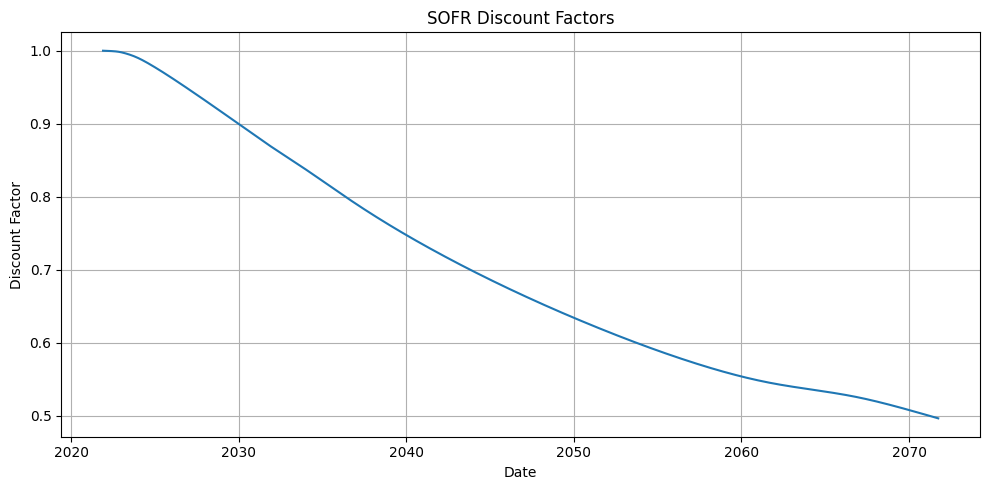

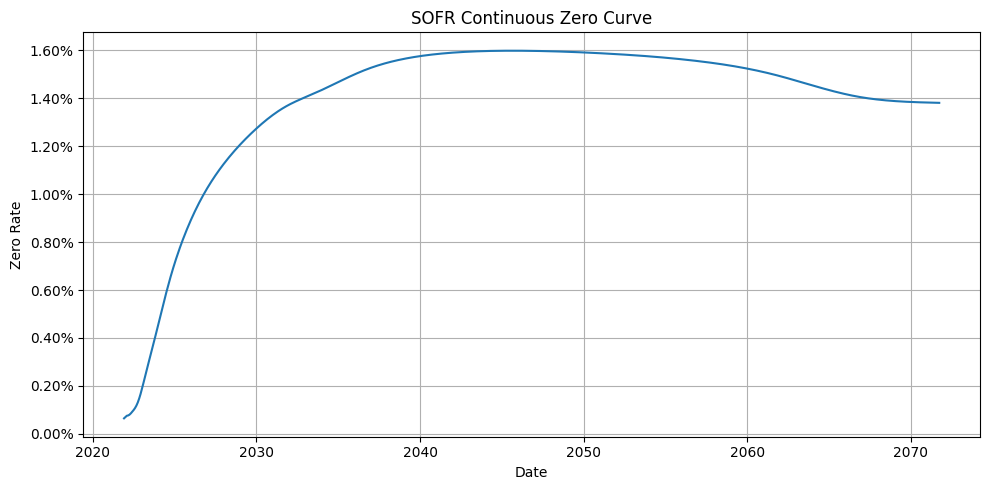

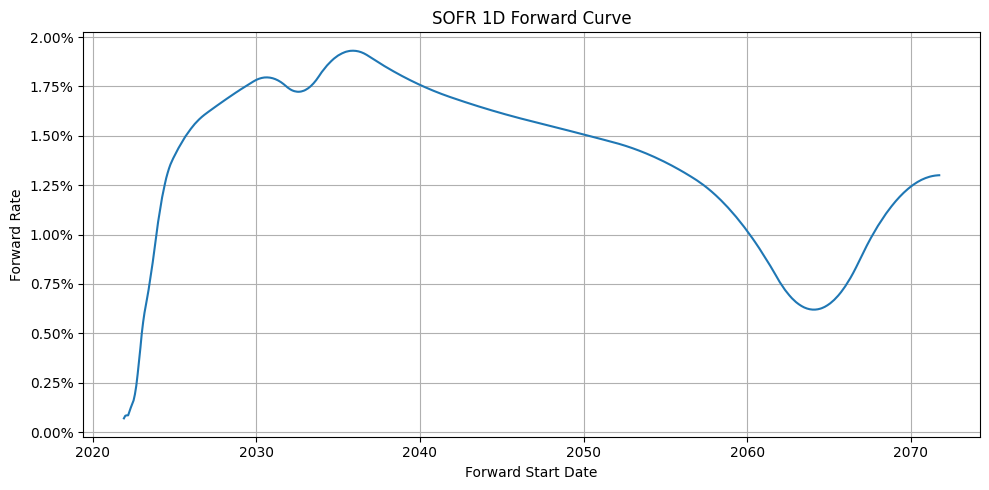

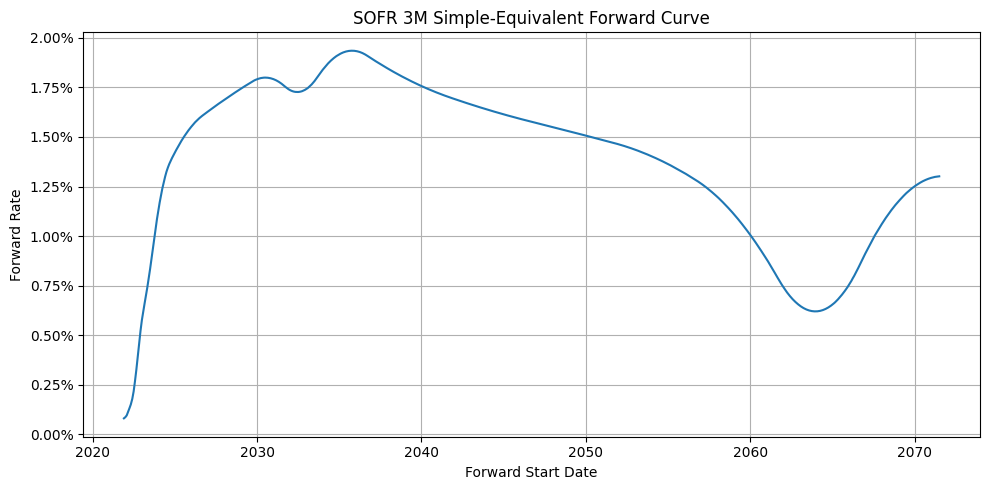

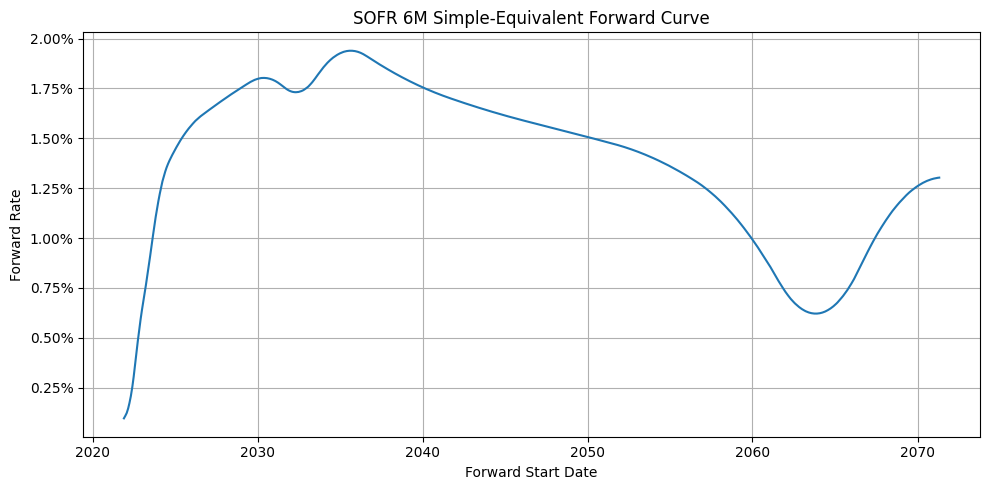

In [71]:
plot_discount_curve(snapshot)
plot_zero_curve(snapshot)

plot_forward_curve(
    snapshot,
    "forward_1d",
    "SOFR 1D Forward Curve",
)

plot_forward_curve(
    snapshot,
    "forward_3m",
    "SOFR 3M Simple-Equivalent Forward Curve",
)

plot_forward_curve(
    snapshot,
    "forward_6m",
    "SOFR 6M Simple-Equivalent Forward Curve",
)

In [72]:
INTERPOLATIONS = [
    "log_cubic_discount",
    "linear_zero",
    "flat_forward",
]

In [73]:
curve_results = {
    interpolation: build_sofr_curve(
        evaluation_date=ql.Date(
            25,
            ql.October,
            2021,
        ),
        futures_specs=FUTURES_DATA,
        ois_specs=OIS_DATA,
        interpolation=interpolation,
    )
    for interpolation in INTERPOLATIONS
}

In [74]:
repricing_tables = {}

for name, curve_result in curve_results.items():
    table = independent_ois_repricing_table(
        result=curve_result,
        ois_specs=OIS_DATA,
        settlement_days=2,
    )

    table["interpolation"] = name
    repricing_tables[name] = table

In [75]:
repricing_summary = pd.DataFrame(
    [
        {
            "interpolation": name,
            "max_helper_error_bp": (
                curve_result
                .helper_diagnostics[
                    "quote_error_bp"
                ]
                .abs()
                .max()
            ),
            "max_independent_error_bp": (
                repricing_tables[name][
                    "fair_rate_error_bp"
                ]
                .abs()
                .max()
            ),
            "max_abs_par_swap_npv": (
                repricing_tables[name][
                    "market_rate_swap_npv"
                ]
                .abs()
                .max()
            ),
        }
        for name, curve_result
        in curve_results.items()
    ]
)

display(repricing_summary)

,interpolation,max_helper_error_bp,max_independent_error_bp,max_abs_par_swap_npv
0,log_cubic_discount,4.298926e-08,5.130679e-09,1.035365e-06
1,linear_zero,4.490235e-03,1.528829e-09,5.405745e-06
2,flat_forward,1.758244e-02,2.458450e-10,2.024899e-07


In [76]:
snapshots = {}

for name, curve_result in curve_results.items():
    table = build_curve_snapshot(
        curve_result.curve,
        calendar=calendar,
    )

    table["interpolation"] = name
    snapshots[name] = table

all_snapshots = pd.concat(
    snapshots.values(),
    ignore_index=True,
)

In [77]:
zero_comparison = all_snapshots.pivot(
    index="date",
    columns="interpolation",
    values="zero_rate",
)

forward_1d_comparison = all_snapshots.pivot(
    index="date",
    columns="interpolation",
    values="forward_1d",
)

forward_3m_comparison = all_snapshots.pivot(
    index="date",
    columns="interpolation",
    values="forward_3m",
)

forward_6m_comparison = all_snapshots.pivot(
    index="date",
    columns="interpolation",
    values="forward_6m",
)

In [78]:
def add_pairwise_differences_bp(
    comparison: pd.DataFrame,
) -> pd.DataFrame:
    result = comparison.copy()

    result[
        "log_cubic_minus_linear_zero_bp"
    ] = (
        result["log_cubic_discount"]
        - result["linear_zero"]
    ) / 1e-4

    result[
        "log_cubic_minus_flat_forward_bp"
    ] = (
        result["log_cubic_discount"]
        - result["flat_forward"]
    ) / 1e-4

    result[
        "linear_zero_minus_flat_forward_bp"
    ] = (
        result["linear_zero"]
        - result["flat_forward"]
    ) / 1e-4

    return result

zero_differences = (
    add_pairwise_differences_bp(
        zero_comparison
    )
)

forward_1d_differences = (
    add_pairwise_differences_bp(
        forward_1d_comparison
    )
)

forward_3m_differences = (
    add_pairwise_differences_bp(
        forward_3m_comparison
    )
)

forward_6m_differences = (
    add_pairwise_differences_bp(
        forward_6m_comparison
    )
)

In [79]:
def plot_curve_comparison(
    comparison: pd.DataFrame,
    title: str,
) -> None:
    plt.figure(figsize=(10, 5))

    for column in comparison.columns:
        plt.plot(
            comparison.index,
            comparison[column],
            label=column,
        )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Rate")
    plt.gca().yaxis.set_major_formatter(
        PercentFormatter(1.0)
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

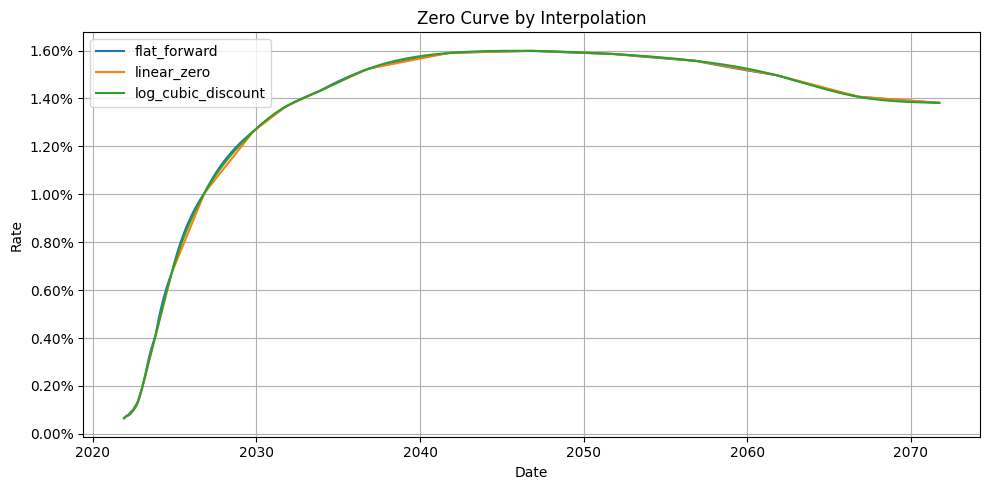

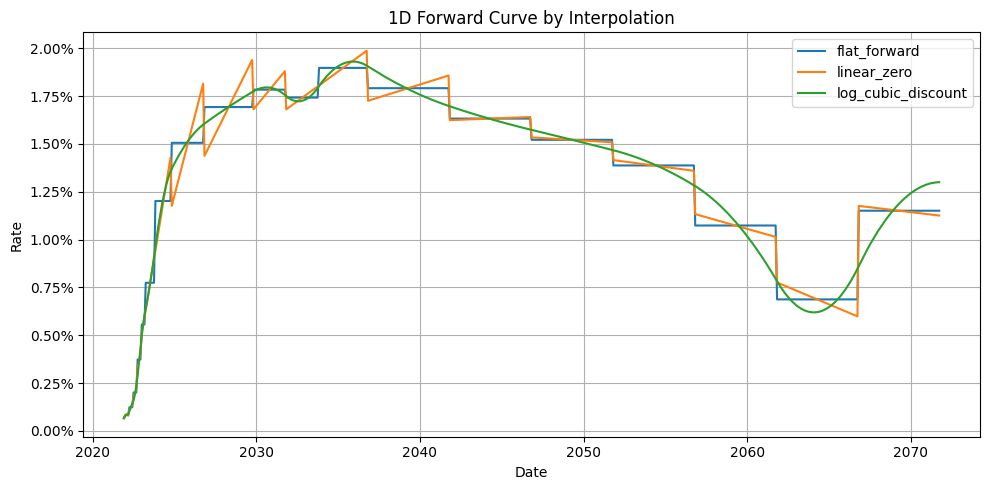

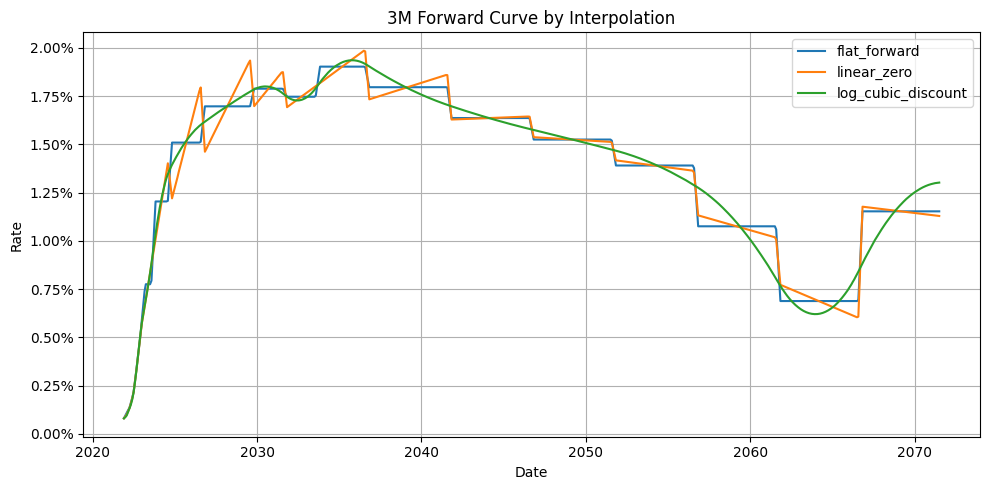

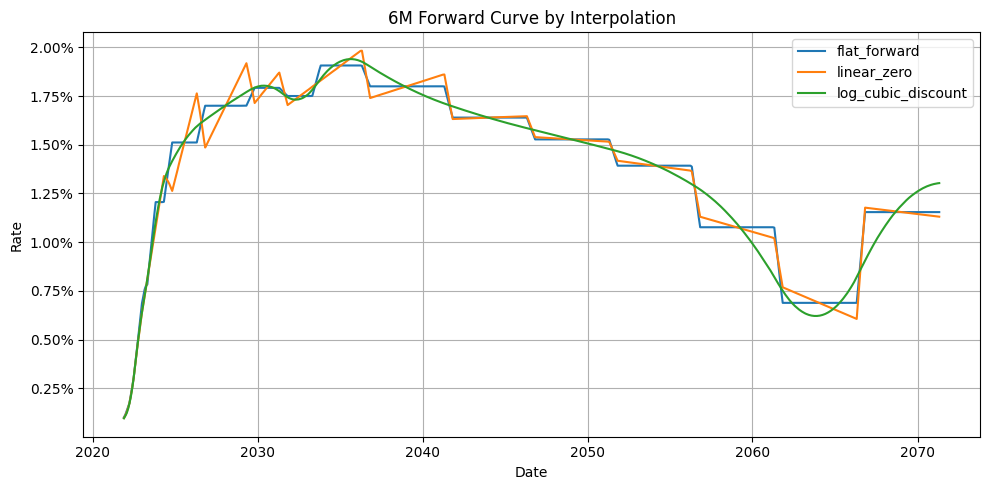

In [80]:
plot_curve_comparison(
    zero_comparison,
    "Zero Curve by Interpolation",
)

plot_curve_comparison(
    forward_1d_comparison,
    "1D Forward Curve by Interpolation",
)

plot_curve_comparison(
    forward_3m_comparison,
    "3M Forward Curve by Interpolation",
)

plot_curve_comparison(
    forward_6m_comparison,
    "6M Forward Curve by Interpolation",
)

In [81]:
def detect_forward_spikes(
    snapshot: pd.DataFrame,
    *,
    forward_column: str = "forward_1d",
    minimum_jump_bp: float = 5.0,
    robust_sigma_threshold: float = 8.0,
) -> pd.DataFrame:
    data = (
        snapshot[
            ["date", forward_column]
        ]
        .dropna()
        .copy()
    )

    data["forward_jump_bp"] = (
        data[forward_column].diff() / 1e-4
    )

    valid_jumps = (
        data["forward_jump_bp"]
        .dropna()
    )

    if valid_jumps.empty:
        data["is_spike"] = False
        return data

    median_jump = valid_jumps.median()

    mad = (
        valid_jumps - median_jump
    ).abs().median()

    robust_sigma = 1.4826 * mad

    if robust_sigma == 0.0:
        statistical_threshold = (
            minimum_jump_bp
        )
    else:
        statistical_threshold = (
            robust_sigma_threshold
            * robust_sigma
        )

    final_threshold = max(
        minimum_jump_bp,
        statistical_threshold,
    )

    data["is_spike"] = (
        (
            data["forward_jump_bp"]
            - median_jump
        )
        .abs()
        > final_threshold
    )

    data["threshold_bp"] = final_threshold

    return data

In [82]:
spikes = detect_forward_spikes(
    snapshots["log_cubic_discount"]
)

print(
    spikes.loc[
        spikes["is_spike"]
    ]
)

          date  forward_1d  forward_jump_bp  is_spike  threshold_bp
10  2022-09-29    0.002940         5.968748      True           5.0
11  2022-10-31    0.003619         6.790149      True           5.0
12  2022-11-30    0.004283         6.643770      True           5.0
13  2022-12-30    0.005000         7.164616      True           5.0
14  2023-01-30    0.005580         5.804719      True           5.0
21  2023-08-31    0.008589         4.914268      True           5.0
22  2023-09-29    0.009089         5.005241      True           5.0
23  2023-10-30    0.009613         5.239682      True           5.0
24  2023-11-30    0.010144         5.308125      True           5.0
25  2023-12-29    0.010633         4.894302      True           5.0


In [83]:
def nearest_pillar_table(
    *,
    spike_dates: pd.Series,
    selected_records: list[HelperRecord],
) -> pd.DataFrame:
    pillars = pd.DataFrame(
        [
            {
                "label": record.label,
                "instrument_type":
                    record.instrument_type,
                "pillar_date":
                    record.helper.pillarDate()
                    .to_date(),
            }
            for record in selected_records
        ]
    )

    rows = []

    for spike_date in spike_dates:
        distances = (
            pillars["pillar_date"]
            .apply(
                lambda pillar:
                    abs(
                        (
                            pillar
                            - spike_date
                        ).days
                    )
            )
        )

        nearest_index = distances.idxmin()
        nearest = pillars.loc[nearest_index]

        rows.append(
            {
                "spike_date": spike_date,
                "nearest_instrument":
                    nearest["label"],
                "nearest_pillar_date":
                    nearest["pillar_date"],
                "distance_days":
                    distances.loc[nearest_index],
            }
        )

    return pd.DataFrame(rows)

In [84]:
flagged_dates = spikes.loc[
    spikes["is_spike"],
    "date",
]

spike_pillars = nearest_pillar_table(
    spike_dates=flagged_dates,
    selected_records=result.selected_records,
)

print(spike_pillars)

   spike_date nearest_instrument nearest_pillar_date  distance_days
0  2022-09-29          SR3_JUN22          2022-09-21              8
1  2022-10-31          SR3_JUN22          2022-09-21             40
2  2022-11-30          SR3_SEP22          2022-12-21             21
3  2022-12-30          SR3_SEP22          2022-12-21              9
4  2023-01-30          SR3_SEP22          2022-12-21             40
5  2023-08-31             OIS_2Y          2023-10-27             57
6  2023-09-29             OIS_2Y          2023-10-27             28
7  2023-10-30             OIS_2Y          2023-10-27              3
8  2023-11-30             OIS_2Y          2023-10-27             34
9  2023-12-29             OIS_2Y          2023-10-27             63


In [85]:
def build_validation_summary(
    *,
    result: SofrCurveBuildResult,
    independent_repricing: pd.DataFrame,
    snapshot: pd.DataFrame,
) -> dict[str, float | int | bool]:
    node_discount_factors = (
        result.nodes["discount_factor"]
    )

    forward_spikes = detect_forward_spikes(
        snapshot
    )

    helper_max_error_bp = (
        result.helper_diagnostics[
            "quote_error_bp"
        ]
        .abs()
        .max()
    )

    independent_max_error_bp = (
        independent_repricing[
            "fair_rate_error_bp"
        ]
        .abs()
        .max()
    )

    return {
        "reference_df": result.curve.discount(
            result.curve.referenceDate()
        ),
        "all_discount_factors_finite": bool(
            np.isfinite(
                node_discount_factors
            ).all()
        ),
        "all_discount_factors_positive": bool(
            (
                node_discount_factors > 0.0
            ).all()
        ),
        "max_helper_error_bp":
            helper_max_error_bp,
        "max_independent_error_bp":
            independent_max_error_bp,
        "max_abs_par_swap_npv": (
            independent_repricing[
                "market_rate_swap_npv"
            ]
            .abs()
            .max()
        ),
        "number_of_forward_spikes": int(
            forward_spikes[
                "is_spike"
            ].sum()
        ),
        "number_of_curve_nodes": int(
            len(result.nodes)
        ),
        "number_of_selected_helpers": int(
            len(result.selected_records)
        ),
    }

In [86]:
validation_summary = (
    build_validation_summary(
        result=result,
        independent_repricing=(
            independent_repricing
        ),
        snapshot=snapshot,
    )
)

print(validation_summary)

{'reference_df': 1.0, 'all_discount_factors_finite': True, 'all_discount_factors_positive': True, 'max_helper_error_bp': 4.298925659895758e-08, 'max_independent_error_bp': 4.764938443813094e-10, 'max_abs_par_swap_npv': 9.319628588855267e-07, 'number_of_forward_spikes': 10, 'number_of_curve_nodes': 23, 'number_of_selected_helpers': 22}


In [87]:
def assert_curve_valid(
    *,
    result: SofrCurveBuildResult,
    independent_repricing: pd.DataFrame,
    helper_tolerance_bp: float = 1e-4,
    independent_tolerance_bp: float = 1e-4,
) -> None:
    reference_df = result.curve.discount(
        result.curve.referenceDate()
    )

    if not np.isclose(
        reference_df,
        1.0,
        atol=1e-12,
        rtol=0.0,
    ):
        raise AssertionError(
            "Discount factor at reference "
            "date is not one."
        )

    discount_factors = (
        result.nodes["discount_factor"]
        .to_numpy()
    )

    if not np.isfinite(
        discount_factors
    ).all():
        raise AssertionError(
            "Curve contains non-finite "
            "discount factors."
        )

    if not (
        discount_factors > 0.0
    ).all():
        raise AssertionError(
            "Curve contains non-positive "
            "discount factors."
        )

    max_helper_error = (
        result.helper_diagnostics[
            "quote_error_bp"
        ]
        .abs()
        .max()
    )

    if max_helper_error > helper_tolerance_bp:
        raise AssertionError(
            "Helper repricing failed: "
            f"{max_helper_error:.8f} bp."
        )

    max_independent_error = (
        independent_repricing[
            "fair_rate_error_bp"
        ]
        .abs()
        .max()
    )

    if (
        max_independent_error
        > independent_tolerance_bp
    ):
        raise AssertionError(
            "Independent OIS repricing failed: "
            f"{max_independent_error:.8f} bp."
        )

In [88]:
assert_curve_valid(
    result=result,
    independent_repricing=(
        independent_repricing
    ),
)